In [17]:
import pandas as pd
from google.colab import drive

#Definir ruta
drive.mount('/content/drive')
path = "/content/drive/MyDrive/proyecto/data/"

#Cargar los archivos
df_precipitacion_veracruz = pd.read_csv(path + 'precipitacion_veracruz.csv')
df_radiacion = pd.read_csv(path + 'radiacion.csv')
df_normales_veracruz = pd.read_csv(path + 'normales_veracruz.csv')
df_emisiones = pd.read_csv(path + 'emisiones.csv')

# --- formato de Fecha ---
df_precipitacion_veracruz['Fecha'] = pd.to_datetime(df_precipitacion_veracruz['Fecha'])
df_radiacion['Fecha'] = pd.to_datetime(df_radiacion['Fecha'])

# ---- MERGE ---

# Unir con Radiación usando la FECHA
df_final = pd.merge(df_precipitacion_veracruz,
                    df_radiacion[['Fecha', 'RH2M', 'ALLSKY_SFC_SW_DWN']],
                    on='Fecha', how='left')

# Unir con Normales usando Municipio y MES_NUM
df_final = pd.merge(df_final,
                    df_normales_veracruz[['MUNICIPIO', 'MES_NUM', 'PRECIPITACION']],
                    left_on=['Municipio', 'MES_NUM'],
                    right_on=['MUNICIPIO', 'MES_NUM'],
                    how='left')

# Unir con Emisiones usando MUNICIPIO
df_final = pd.merge(df_final, df_emisiones, on='Municipio', how='left')

# Limpieza de columnas repetidas
if 'MUNICIPIO' in df_final.columns:
    df_final = df_final.drop(columns=['MUNICIPIO'])

# 4. Guardar el Archivo
df_final.to_csv(path + 'dataset_final_veracruz.csv', index=False)

print(f"¡LOGRADO! El archivo único se guardó en: {path}dataset_final_veracruz.csv")
df_final.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¡LOGRADO! El archivo único se guardó en: /content/drive/MyDrive/proyecto/data/dataset_final_veracruz.csv


,Fecha,Precip,Evap,Tmax,Tmin,ID_Estacion,Municipio,MES_NUM,RH2M,ALLSKY_SFC_SW_DWN,PRECIPITACION,SO_2,CO,NOx,PM_010,PM_2_5
0,2011-01-01,0.00,1.85,24,16,30357,TAMIAHUA,1,57.74,4.2607,44.6,4.836,1091.601,178.401,167.523,121.161
1,2011-01-02,0.00,3.7,23,15,30357,TAMIAHUA,1,66.27,3.7831,44.6,4.836,1091.601,178.401,167.523,121.161
2,2011-01-03,0.00,0.7,22,16,30357,TAMIAHUA,1,75.52,3.0686,44.6,4.836,1091.601,178.401,167.523,121.161
3,2011-01-04,0.01,1.6,25,18,30357,TAMIAHUA,1,77.74,4.6654,44.6,4.836,1091.601,178.401,167.523,121.161
4,2011-01-05,0.00,2.13,28,17,30357,TAMIAHUA,1,75.02,5.0042,44.6,4.836,1091.601,178.401,167.523,121.161


In [19]:
import pandas as pd

# 1. Cargar el archivo que se unieron
path = "/content/drive/MyDrive/proyecto/data/"
df = pd.read_csv(path + 'dataset_final_veracruz.csv')

# Crear la columna binarizada
# Si la precipitación es mayor a 0, ponemos 1 significa que llovió.
# Si es 0 o menor, ponemos 0 significa que no llovió.
df['lluvia_binaria'] = (df['Precip'] > 0).astype(int)

# Verificar el balance de los datos
print("Conteo de días con y sin lluvia:")
print(df['lluvia_binaria'].value_counts())

# Muestra las primeras filas para verificar la nueva columna
print("\nVerificación de la nueva columna:")
print(df[['Fecha', 'Municipio', 'Precip', 'lluvia_binaria']].head(10))

# 5. Guardar el progreso
df.to_csv(path + 'dataset_final_veracruz.csv', index=False)

Conteo de días con y sin lluvia:
lluvia_binaria
0    39733
1    18797
Name: count, dtype: int64

Verificación de la nueva columna:
        Fecha Municipio  Precip  lluvia_binaria
0  2011-01-01  TAMIAHUA    0.00               0
1  2011-01-02  TAMIAHUA    0.00               0
2  2011-01-03  TAMIAHUA    0.00               0
3  2011-01-04  TAMIAHUA    0.01               1
4  2011-01-05  TAMIAHUA    0.00               0
5  2011-01-06  TAMIAHUA    0.00               0
6  2011-01-07  TAMIAHUA    0.01               1
7  2011-01-08  TAMIAHUA    0.00               0
8  2011-01-09  TAMIAHUA    0.00               0
9  2011-01-10  TAMIAHUA    0.00               0


In [21]:
import pandas as pd

# Cargar el archivo
path = "/content/drive/MyDrive/proyecto/data/"
df = pd.read_csv(path + 'dataset_final_veracruz.csv')

# Orden sea cronológico de las fechas
df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df.sort_values(by=['Municipio', 'Fecha'])

# Creamos el lag de Radiación (ALLSKY_SFC_SW_DWN) por cada municipio
df['radiacion_lag1'] = df.groupby('Municipio')['ALLSKY_SFC_SW_DWN'].shift(1)

# Medias regionales Contaminantes
df['pm10_media_municipio'] = df.groupby('Municipio')['PM_010'].transform('mean')
df['nox_media_municipio'] = df.groupby('Municipio')['NOx'].transform('mean')

# Revisar los resultados
print("Nuevas columnas creadas:")
print(df[['Municipio', 'Fecha', 'ALLSKY_SFC_SW_DWN', 'radiacion_lag1', 'pm10_media_municipio']].head(5))

# Guardar cambios
df.to_csv(path + 'dataset_final_veracruz.csv', index=False)

Nuevas columnas creadas:
  Municipio      Fecha  ALLSKY_SFC_SW_DWN  radiacion_lag1  \
0   ACTOPAN 2011-01-01             4.2607             NaN   
1   ACTOPAN 2011-01-02             3.7831          4.2607   
2   ACTOPAN 2011-01-03             3.0686          3.7831   
3   ACTOPAN 2011-01-04             4.6654          3.0686   
4   ACTOPAN 2011-01-05             5.0042          4.6654   

   pm10_media_municipio  
0               320.573  
1               320.573  
2               320.573  
3               320.573  
4               320.573  


In [22]:
import pandas as pd

# Cargar el archivo con los lags
path = "/content/drive/MyDrive/proyecto/data/"
df = pd.read_csv(path + 'dataset_final_veracruz.csv')

# Identificar valores vacíos
print("Valores vacíos antes de la interpolación:")
print(df[['radiacion_lag1', 'PM_010', 'RH2M']].isnull().sum())

# interpolacion por municipio
df = df.sort_values(by=['Municipio', 'Fecha'])
columnas_a_interpolar = ['radiacion_lag1', 'RH2M', 'ALLSKY_SFC_SW_DWN', 'PRECIPITACION']

for col in columnas_a_interpolar:
    if col in df.columns:
        df[col] = df.groupby('Municipio')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

# relleno de espacios vacios de contaminantes
df['PM_010'] = df['PM_010'].fillna(df['pm10_media_municipio'])
df['NOx'] = df['NOx'].fillna(df['nox_media_municipio'])

# Verificación
print("\nValores vacíos después de la interpolación:")
print(df[['radiacion_lag1', 'PM_010', 'RH2M']].isnull().sum())

# Guardar el archivo
df.to_csv(path + 'dataset_final_veracruz.csv', index=False)

Valores vacíos antes de la interpolación:
radiacion_lag1    18
PM_010             0
RH2M               0
dtype: int64

Valores vacíos después de la interpolación:
radiacion_lag1    0
PM_010            0
RH2M              0
dtype: int64


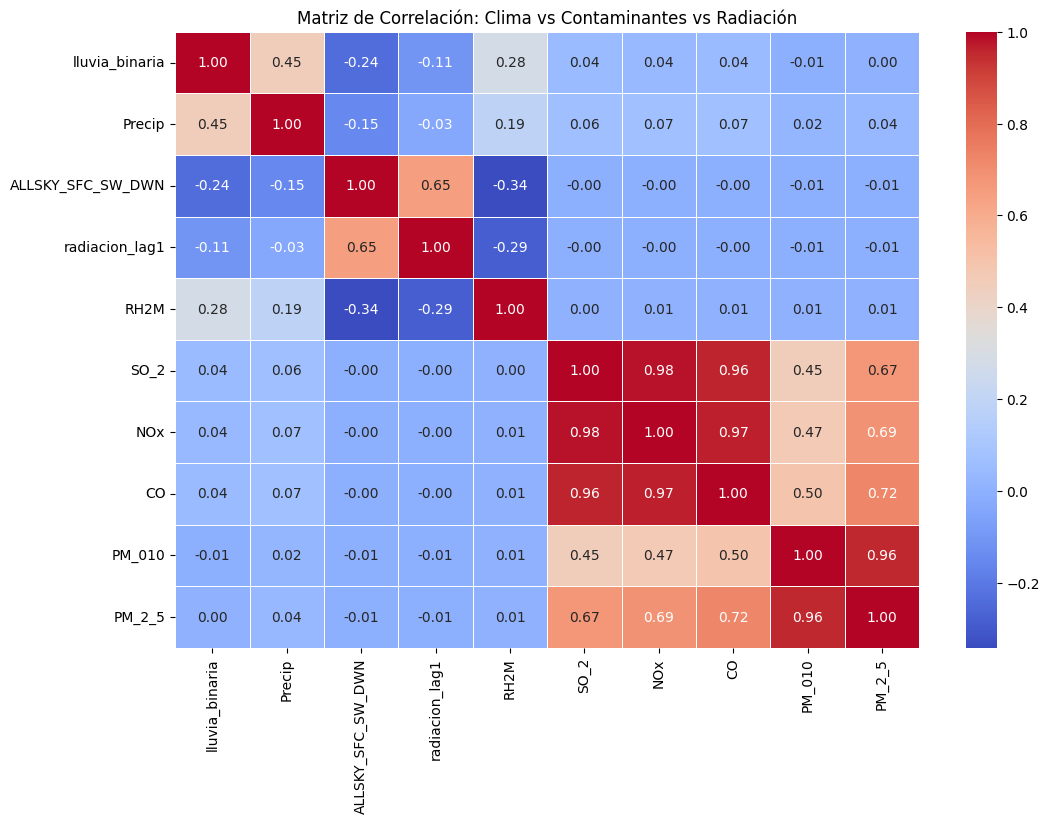


Correlación directa con la lluvia:
lluvia_binaria       1.000000
Precip               0.448832
RH2M                 0.280644
SO_2                 0.043508
CO                   0.042121
NOx                  0.039345
PM_2_5               0.003042
PM_010              -0.010820
radiacion_lag1      -0.107545
ALLSKY_SFC_SW_DWN   -0.241102
Name: lluvia_binaria, dtype: float64


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset
path = "/content/drive/MyDrive/proyecto/data/"
df = pd.read_csv(path + 'dataset_final_veracruz.csv')

# Seleccionar las variables que queremos analizar como la lluvia, radiación con lag y contaminantes
columnas_analisis = [
    'lluvia_binaria', 'Precip', 'ALLSKY_SFC_SW_DWN', 'radiacion_lag1',
    'RH2M', 'SO_2', 'NOx', 'CO', 'PM_010', 'PM_2_5'
]

#Calculamos la correlación
corr_matrix = df[columnas_analisis].corr()

# Graficar el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Clima vs Contaminantes vs Radiación')
plt.show()

# Insight
print("\nCorrelación directa con la lluvia:")
print(corr_matrix['lluvia_binaria'].sort_values(ascending=False))

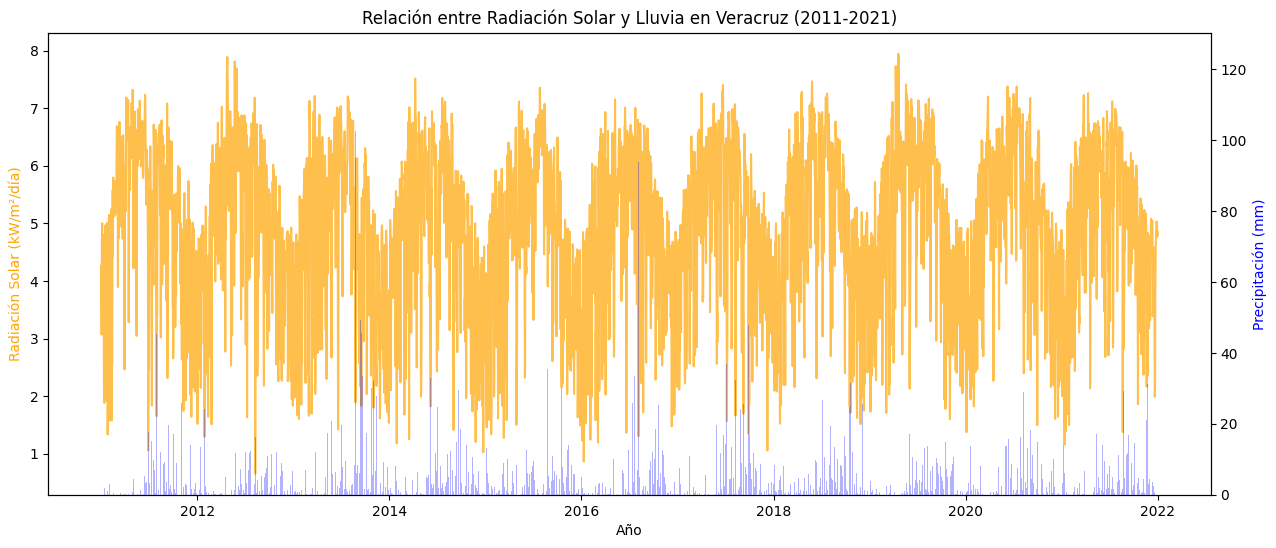

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
path = "/content/drive/MyDrive/proyecto/data/"
df = pd.read_csv(path + 'dataset_final_veracruz.csv')
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Agrupar por fecha para ver la tendencia promedio
df_diario = df.groupby('Fecha')[['Precip', 'ALLSKY_SFC_SW_DWN', 'RH2M']].mean().reset_index()

# Grafica de Comparación
plt.figure(figsize=(15, 6))
ax1 = plt.gca() # Radiación
ax2 = ax1.twinx() # Precipitación

ax1.plot(df_diario['Fecha'], df_diario['ALLSKY_SFC_SW_DWN'], color='orange', alpha=0.7, label='Radiación Solar')
ax2.bar(df_diario['Fecha'], df_diario['Precip'], color='blue', alpha=0.3, label='Precipitación (Lluvia)')

ax1.set_xlabel('Año')
ax1.set_ylabel('Radiación Solar (kW/m²/día)', color='orange')
ax2.set_ylabel('Precipitación (mm)', color='blue')
plt.title('Relación entre Radiación Solar y Lluvia en Veracruz (2011-2021)')
plt.show()


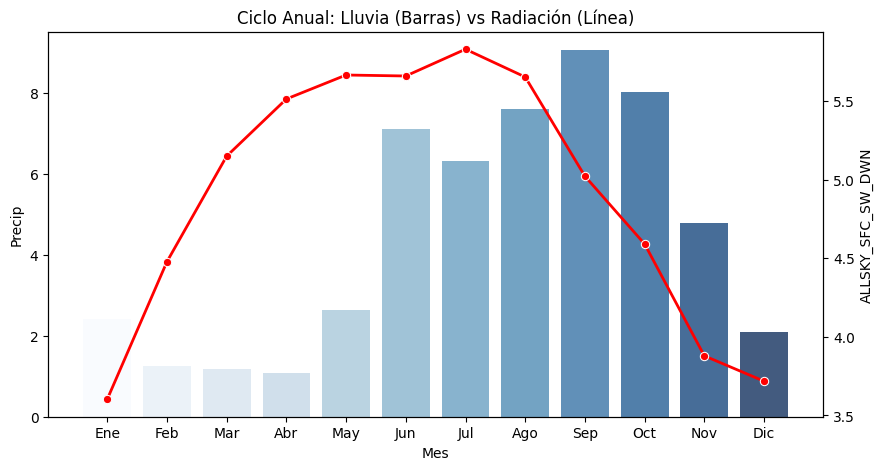

In [29]:
# Grafica de promedio mensual
df['Mes'] = df['Fecha'].dt.month
df_mensual = df.groupby('Mes')[['Precip', 'ALLSKY_SFC_SW_DWN']].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Mes', y='Precip', data=df_mensual, hue='Mes', palette='Blues', legend=False, alpha=0.8)
plt.twinx()
sns.lineplot(x=df_mensual['Mes']-1, y=df_mensual['ALLSKY_SFC_SW_DWN'], color='red', marker='o', linewidth=2)
plt.title('Ciclo Anual: Lluvia (Barras) vs Radiación (Línea)')
plt.xticks(range(0, 12), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.show()

In [30]:
import pandas as pd

# Cargar el dataset
path = "/content/drive/MyDrive/proyecto/data/"
df = pd.read_csv(path + 'dataset_final_veracruz.csv')
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Split Temporal Entrenamiento hasta 2019
train_df = df[df['Fecha'] <= '2019-12-31']

# Prueba 2020 en adelante
test_df = df[df['Fecha'] >= '2020-01-01']

# Verificación de tamaños
print(f"Registros para entrenamiento (hasta 2019): {train_df.shape[0]}")
print(f"Registros para prueba (2020+): {test_df.shape[0]}")

# Guardar los modelos
train_df.to_csv(path + 'train_data.csv', index=False)
test_df.to_csv(path + 'test_data.csv', index=False)

Registros para entrenamiento (hasta 2019): 47283
Registros para prueba (2020+): 11247


In [32]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar los archivos de Train y Test
path = "/content/drive/MyDrive/proyecto/data/"
train_df = pd.read_csv(path + 'train_data.csv')
test_df = pd.read_csv(path + 'test_data.csv')

# Seleccionar las variables para el modelo
features = ['RH2M', 'ALLSKY_SFC_SW_DWN', 'radiacion_lag1', 'PM_010', 'PM_2_5', 'CO', 'NOx']
target = 'lluvia_binaria'

# Creamos X para la entrada de datos y para predecir la y
X_train = train_df[features].fillna(0) # Rellenar nulos
y_train = train_df[target]

X_test = test_df[features].fillna(0)
y_test = test_df[target]

# Regresión Logística
modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train, y_train)

# Prediccion
y_pred = modelo_log.predict(X_test)


# Accuracy
print(f"Accuracy del modelo: {accuracy_score(y_test, y_pred):.2f}")

# Reporte de Clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Accuracy del modelo: 0.71

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.74      0.91      0.81      7800
           1       0.56      0.26      0.35      3447

    accuracy                           0.71     11247
   macro avg       0.65      0.58      0.58     11247
weighted avg       0.68      0.71      0.67     11247



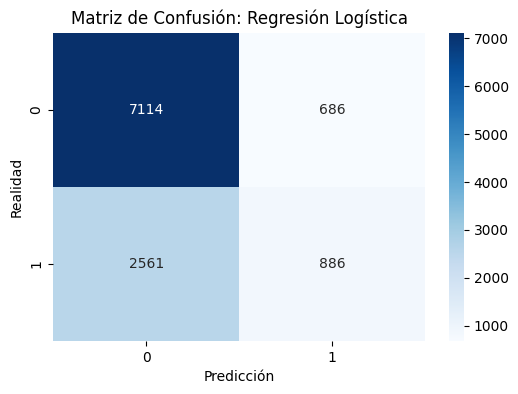

In [33]:
# Matriz de Confusión (Visual)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

In [35]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Random Forest - 100 árboles
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Predicción
y_pred_rf = modelo_rf.predict(X_test)

print("--- EVALUACIÓN: RANDOM FOREST ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.2f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))



--- EVALUACIÓN: RANDOM FOREST ---
Accuracy: 0.70
F1-Score: 0.46

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.76      0.83      0.80      7800
           1       0.52      0.42      0.46      3447

    accuracy                           0.70     11247
   macro avg       0.64      0.62      0.63     11247
weighted avg       0.69      0.70      0.69     11247



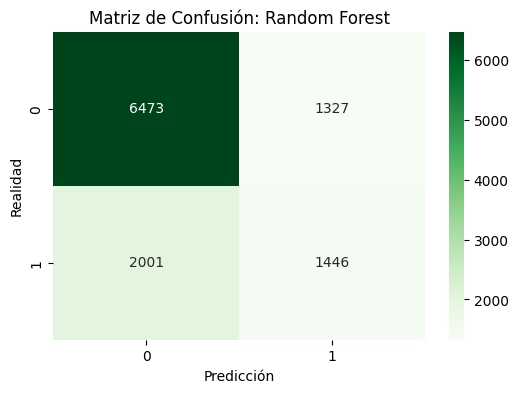

In [36]:
#Matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión: Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()


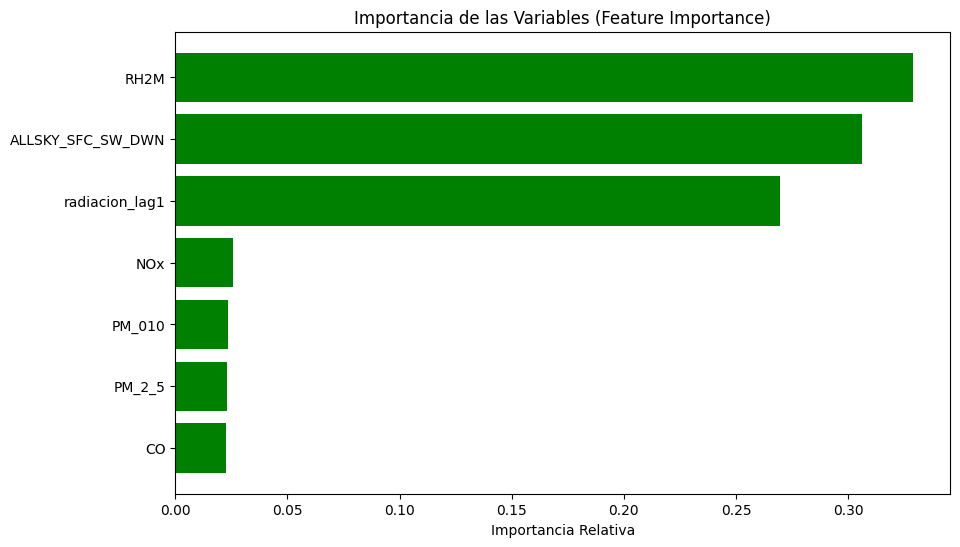

In [37]:
# FEATURE IMPORTANCE
importances = modelo_rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title('Importancia de las Variables (Feature Importance)')
plt.barh(range(len(indices)), importances[indices], color='g', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.show()

In [38]:
!pip install xgboost

In [39]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# XGBoost
modelo_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
modelo_xgb.fit(X_train, y_train)

#Predicción de XGBoost
y_pred_xgb = modelo_xgb.predict(X_test)

print("--- EVALUACIÓN: XGBOOST ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.2f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_xgb))


--- EVALUACIÓN: XGBOOST ---
Accuracy: 0.72
F1-Score: 0.46

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81      7800
           1       0.57      0.39      0.46      3447

    accuracy                           0.72     11247
   macro avg       0.67      0.63      0.64     11247
weighted avg       0.71      0.72      0.71     11247



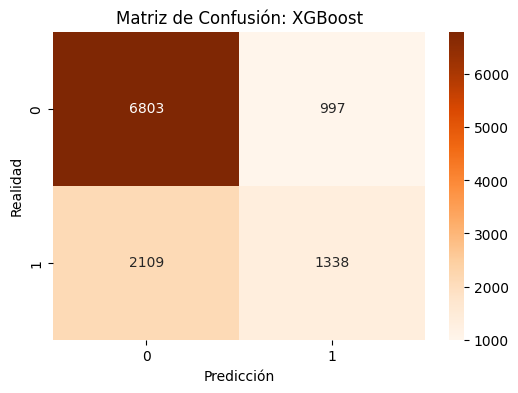

In [40]:
# MATRIZ DE CONFUSIÓN de XGBoost
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión: XGBoost')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

<Figure size 1000x600 with 0 Axes>

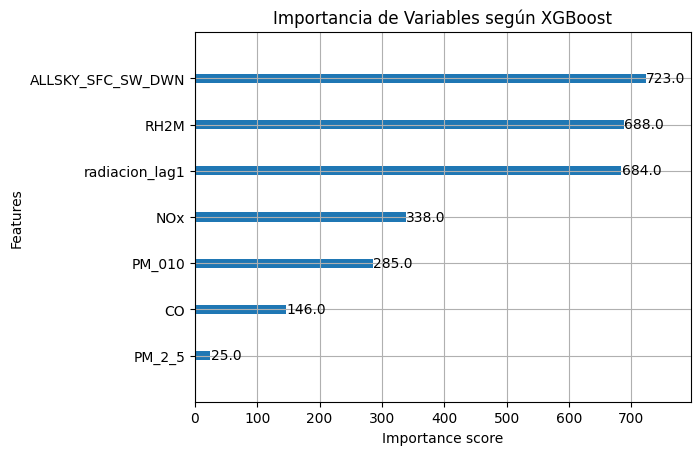

In [41]:
#FEATURE IMPORTANCE de XGBoost
from xgboost import plot_importance
plt.figure(figsize=(10,6))
plot_importance(modelo_xgb, importance_type='weight')
plt.title('Importancia de Variables según XGBoost')
plt.show()

352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


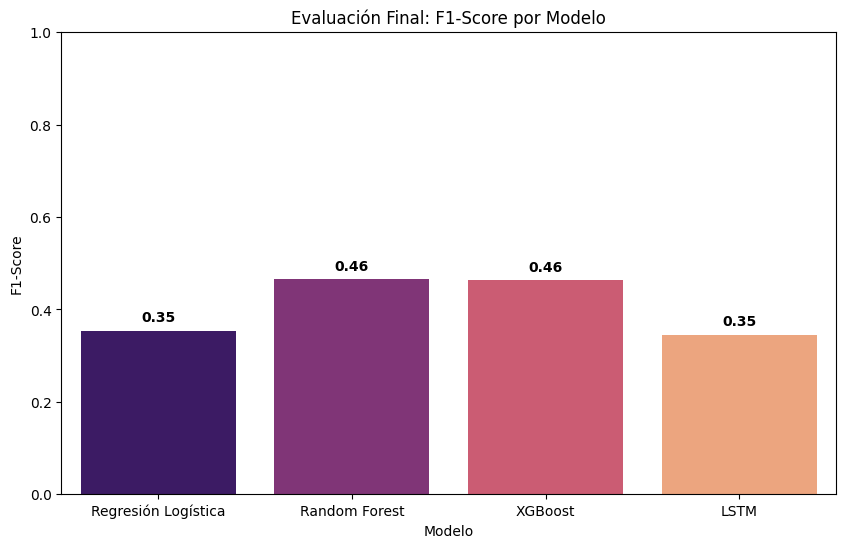

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras import layers, models

# Entrenamiento
model_lstm = models.Sequential([
    layers.Input(shape=(1, X_train_scaled.shape[1])),
    layers.LSTM(50, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(25, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=0)

# Cálculo de métricas
y_pred_lstm = (model_lstm.predict(X_test_lstm) > 0.5).astype(int)
f1_lstm = f1_score(y_test, y_pred_lstm)
f1_log = f1_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred_rf)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Gráfica comparativa
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'XGBoost', 'LSTM'],
    'F1-Score': [f1_log, f1_rf, f1_xgb, f1_lstm]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='F1-Score', data=resultados, hue='Modelo', palette='magma', legend=False)
plt.title('Evaluación Final: F1-Score por Modelo')
plt.ylim(0, 1)
for i, val in enumerate(resultados['F1-Score']):
    plt.text(i, val + 0.02, f'{val:.2f}', ha='center', fontweight='bold')
plt.show()

In [49]:
# --- EVALUACIÓN ---
print("\n--- EVALUACIÓN: LSTM ---")
print(classification_report(y_test, y_pred_lstm))



--- EVALUACIÓN: LSTM ---
              precision    recall  f1-score   support

           0       0.73      0.92      0.82      7800
           1       0.58      0.25      0.35      3447

    accuracy                           0.71     11247
   macro avg       0.66      0.58      0.58     11247
weighted avg       0.69      0.71      0.67     11247



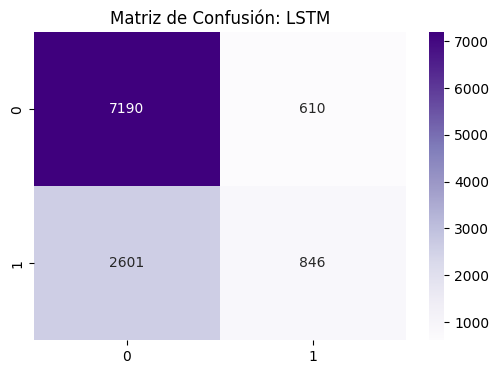

In [48]:
# MATRIZ DE CONFUSIÓN
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lstm), annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de Confusión: LSTM')
plt.show()